             T=0.5     T=1.0     T=2.0
dog       0.838383  0.587098  0.393829
cat       0.113463  0.215981  0.238869
book      0.041741  0.130999  0.186031
tree      0.005649  0.048192  0.112834
airplane  0.000765  0.017729  0.068437
SUM       1.000000  1.000000  1.000000


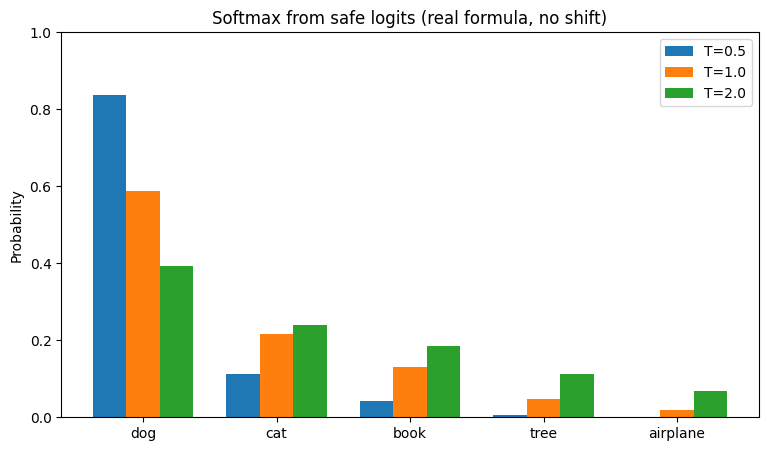

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

words = ["dog", "cat", "book", "tree", "airplane"]
logits = np.array([2.0, 1.0, 0.5, -0.5, -1.5])


def softmax_with_temp_no_shift(logits, T):
**************
    exp_vals = np.exp(scaled)
    return exp_vals / np.sum(exp_vals)


**************

dists = {
    f"T={T}": softmax_with_temp_no_shift(logits, T)
    for T in temps
}

df = pd.DataFrame(dists, index=words)
df.loc["SUM"] = df.sum(axis=0)

print(df.round(6))


x = np.arange(len(words))
width = 0.25

plt.figure(figsize=(9, 5))

for i, T in enumerate(temps):
    plt.bar(
        x + i * width,
        dists[f"T={T}"],
        width,
        label=f"T={T}"
    )

plt.xticks(x + width, words)
plt.ylabel("Probability")
plt.title("Softmax from safe logits (real formula, no shift)")
plt.ylim(0, 1)
plt.legend()
plt.show()